# Spectral Clustering


In this exercise, you will implement spectral clustering and try it on diffent kinds of data, for instance:

* N-blob: Random points in $\mathbb{R}^2$ according to N Gaussian distributions with different means;

* Two moons: Random points shaped as two intertwined moons;

* Point and circle: random points from a concentrated Gaussian point in the middle and a wide circle around it.

The first step after generating the data is to construct a graph and, for that, we need a similarity function. In this exercise we will use the following similarity:

$$
d(x_i, x_j) = \exp\left(-\frac{||x_i-x_j||_2^2}{2\sigma^2}\right)
$$

Using this similarity, we can compute the weight matrix W representing the graph, compute the graph Laplacian L and finally use its eigenvectors for clustering.


## Setup

In [45]:
from generate_data import worst_case_blob, blobs, two_moons, point_and_circle
from utils import plot_clusters, min_span_tree, plot_graph_matrix, min_span_tree
from utils import plot_clustering_result, plot_the_bend
from sklearn.cluster import KMeans
import sklearn.metrics as skm
import numpy as np
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(750)

## Generating the data

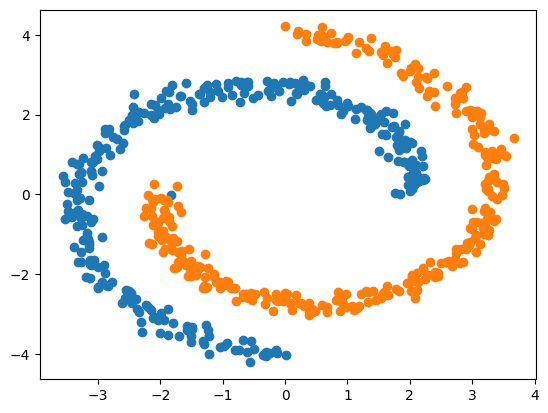

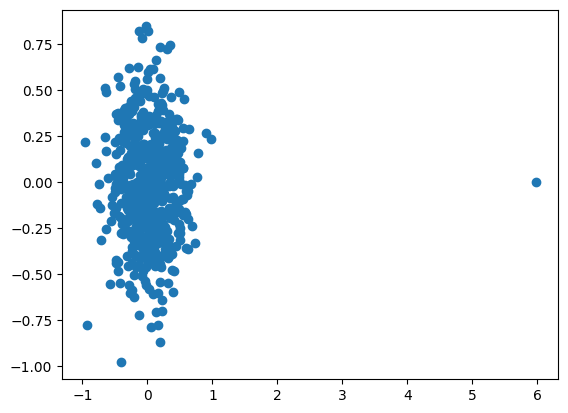

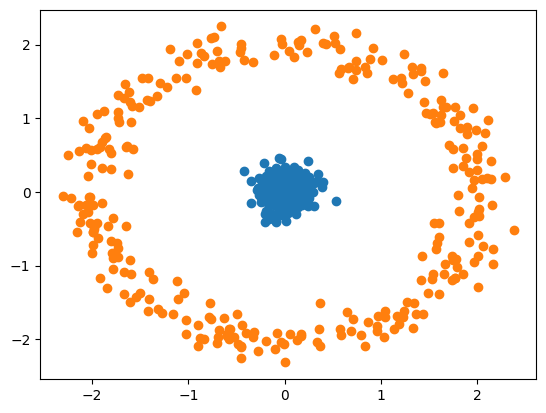

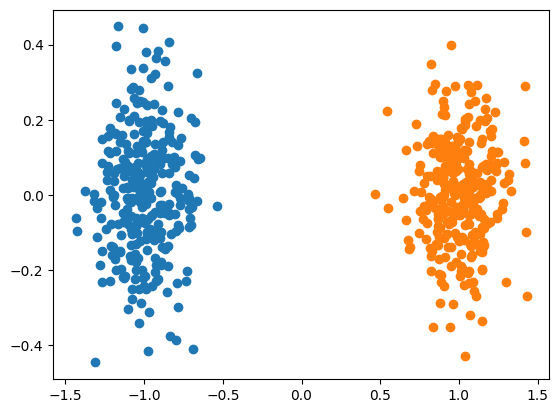

In [46]:
# Example

for fn in [two_moons, worst_case_blob, point_and_circle, blobs]:
    X, Y = fn(num_samples=600)
    plot_clusters(X, Y, fignum=str(fn))

## Building similarity graph

In [47]:
def build_similarity_graph(X, var=1.0, eps=0.0, k=0):
    """
    TO BE COMPLETED.

    Computes the similarity matrix for a given dataset of samples.
    If k=0, builds epsilon graph.
    Otherwise, builds kNN graph.

    Parameters
    ----------
    X : numpy array
        (n x m) matrix of m-dimensional samples
    var : double
        the sigma value for the exponential function, already squared
    eps : double
        threshold for epsilon graphs
    k : int
        The number of neighbours k for k-nn. If zero, use epsilon-graph

    Returns
    -------
        W: (n x n) dimensional matrix representing the weight matrix of the graph
    """
    n = X.shape[0]
    W = np.zeros((n, n))

    """
    Build similarity graph, before threshold or kNN
    similarities: (n x n) matrix with similarities between all possible couples of points.
    The similarity function is d(x,y)=exp(-||x-y||^2/(2*var))
    """

    sq_dist = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :])**2, axis=2)
    similarities = np.exp(-sq_dist / (2 * var))
    np.fill_diagonal(similarities, 0)

    # If epsilon graph
    if k == 0:
        """
        compute an epsilon graph from the similarities
        for each node x_i, an epsilon graph has weights
        w_ij = d(x_i,x_j) when w_ij >= eps, and 0 otherwise
        """
        W = similarities * (similarities >= eps)

    # If kNN graph
    elif k != 0:
        """
        compute a k-nn graph from the similarities
        for each node x_i, a k-nn graph has weights
        w_ij = d(x_i,x_j) for the k closest nodes to x_i, and 0
        for all the k-n remaining nodes
        Remember to remove self similarity and
        make the graph undirected
        """
        # Ensure k is not larger than the number of other points (n-1)
        actual_k = min(k, n - 1)

        for i in range(n):
            # Get the indices of the k largest similarities for node i
            # np.argsort sorts in ascending order, so we take the last 'actual_k' elements
            idx = np.argpartition(similarities[i, :], -actual_k)[-actual_k:]
            W[i, idx] = similarities[i, idx]

        W = (W + W.T) / 2
        np.fill_diagonal(similarities, 0)

    return W

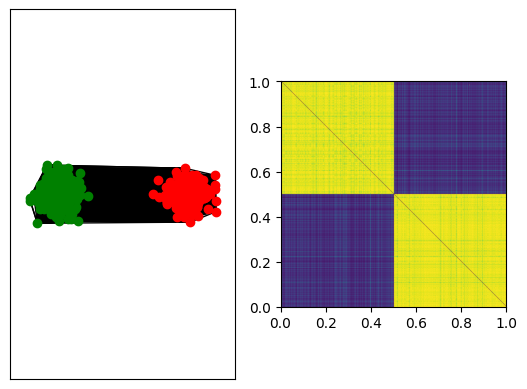

In [48]:
# Example

W = build_similarity_graph(X)
W[0, 599] = 1    # add two placeholder edges to reproduce example picture
W[10, 500] = 1   #


plot_graph_matrix(X, Y, W)  # shows the graph and the visualization of W

## Computing the Laplacian

In [49]:
def build_laplacian(W, laplacian_normalization='unn'):
    """
    Compute graph Laplacian.

    Parameters
    ----------
    W : numpy array
        Adjacency matrix (n x n)
    laplacian_normalization : str
        String selecting which version of the laplacian matrix to construct.
            'unn':  unnormalized,
            'sym': symmetric normalization
            'rw':  random-walk normalization

    Returns
    -------
    L: (n x n) dimensional matrix representing the Laplacian of the graph
    """
    D = np.diag(np.sum(W, axis=1))

    # Unnormalized Laplacian
    if laplacian_normalization == 'unn':
        L = D - W

    # Symmetric Normalized Laplacian
    elif laplacian_normalization == 'sym':
        d_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
        L = np.eye(W.shape[0]) - (d_inv_sqrt @ W @ d_inv_sqrt)

    # Random Walk Normalized Laplacian
    elif laplacian_normalization == 'rw':
        d_inv = np.diag(1.0 / np.diag(D))
        L = np.eye(W.shape[0]) - (d_inv @ W)

    else:
        raise ValueError("Invalid laplacian_normalization. Choose 'unn', 'sym', or 'rw'.")

    return L

## Clustering

In [50]:
import scipy.linalg

def spectral_clustering(L, chosen_eig_indices=None, num_classes=2):
    """
    Parameters
    ----------
    L : numpy array
        Graph Laplacian (standard or normalized)
    chosen_eig_indices : list or None
        Indices of eigenvectors to use for clustering.
        If None, use adaptive choice of eigenvectors.
    num_classes : int
        Number of clusters to compute (defaults to 2)


    Returns
    -------
    Y : numpy array (num_samples, )+
        Cluster assignments
    """

    """
    Use the function scipy.linalg.eig or the function scipy.sparse.linalg.eigs to compute:
    U = (n x n) eigenvector matrix           (sorted)
    E = (n x n) eigenvalue diagonal matrix   (sorted)
    """
    eigvals, eigvecs = scipy.linalg.eigh(L)

    eigvals = np.real(eigvals)
    eigvecs = np.real(eigvecs)

    # Handle trivial cases for clustering
    n_samples = L.shape[0]

    if chosen_eig_indices is None:
        max_k = min(n_samples - 1, 20)
        gaps = np.diff(eigvals[:max_k + 1])
        k_optimal = np.argmax(gaps) + 1

        k = k_optimal if num_classes is None else num_classes
        chosen_eig_indices = np.arange(k)
    else:
        k = len(chosen_eig_indices)

    # Extract the chosen eigenvectors
    U = eigvecs[:, chosen_eig_indices]

    """
    compute the clustering assignment from the eigenvectors
    Y = (n x 1) cluster assignments in [0,1,...,num_classes-1]
    """
    # Normalize the rows of U
    row_norms = np.linalg.norm(U, axis=1, keepdims=True)
    U_normalized = np.divide(U, row_norms, out=np.zeros_like(U), where=row_norms != 0)

    # Apply K-Means clustering to the rows of U_normalized
    kmeans = KMeans(n_clusters=num_classes, random_state=0, n_init=10)
    Y = kmeans.fit_predict(U_normalized)

    return Y

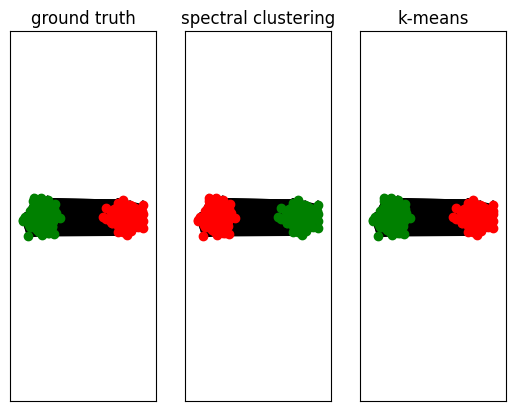

In [51]:
# Example

num_classes = 2
L = build_laplacian(W)
Y_rec = spectral_clustering(L, chosen_eig_indices=[1, 2], num_classes=num_classes)

# Plot results, comparing to KMeans
plot_clustering_result(X, Y, L, Y_rec, KMeans(num_classes).fit_predict(X))

## Parameter sensitivity

In [52]:
def parameter_sensitivity(parameter_type = 'eps', parameter_candidate = [1, 2], num_samples = 500):
    """
    TO BE COMPLETED.

    A function to test spectral clustering sensitivity to parameter choice.
    """

    """
    Choose parameters
    """
    var = 1.0  # exponential_euclidean's sigma^2
    laplacian_normalization = 'unn'
    chosen_eig_indices = None

    """
    Choose candidate parameters
    """
    parameter_performance = []

    for parameter in parameter_candidate:
        # Generate data
        X, Y = two_moons(num_samples, 1, 0.02)
        num_classes = len(np.unique(Y))

        parameter_wrap = {parameter_type: parameter}

        W = build_similarity_graph(X, **parameter_wrap)
        L = build_laplacian(W, laplacian_normalization)

        Y_rec = spectral_clustering(L, chosen_eig_indices, num_classes)

        parameter_performance += [skm.adjusted_rand_score(Y, Y_rec)]

    plt.figure()
    plt.plot(parameter_candidate, parameter_performance)
    plt.title(f'parameter sensitivity ({parameter_type})')
    plt.show()

## Image segmentation

In [53]:
def image_segmentation(input_img="four_elements.bmp", var=1.0, k=20, laplacian_normalization="sym", chosen_eig_indices=None, num_classes=5):
    """
    TO BE COMPLETED

    Function to perform image segmentation.

    :param input_img: name of the image file in /data (e.g. 'four_elements.bmp' or 'fruit_salad.bmp')
    """
    filename = os.path.join("data", input_img)

    X = io.imread(filename)
    X = (X - np.min(X)) / (np.max(X) - np.min(X))

    im_side = np.size(X, 1)
    Xr = X.reshape(im_side**2, 3)
    """
    Y_rec should contain an index from 0 to c-1 where c is the
     number of segments you want to split the image into
    """

    """
    Choose parameters
    """

    W = build_similarity_graph(Xr, var=var, k=k)
    L = build_laplacian(W, laplacian_normalization)
    Y_rec = spectral_clustering(L, chosen_eig_indices, num_classes=num_classes)

    plt.figure()

    plt.subplot(1, 2, 1)
    plt.imshow(X)

    plt.subplot(1, 2, 2)
    Y_rec = Y_rec.reshape(im_side, im_side)
    plt.imshow(Y_rec)

    plt.show()

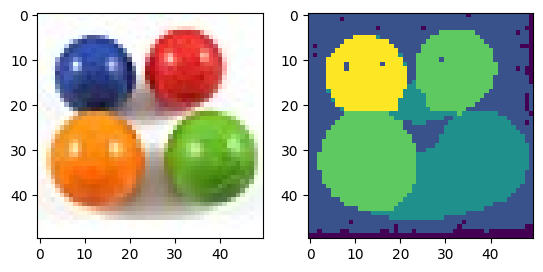

In [54]:
image_segmentation()

# Questions

### Q1.1: What is the purpose of the option parameter in `worst_case_blob`?

The delta parameter option in `worst_case_blob` is used when adding an outlier to the blob. It defines how far the point will be added. This is used to simulate what a worst-case scenario might be for clustering algorithms, with a cluster and a point. See below for an example:

Text(0.5, 1.0, 'Delta = 10')

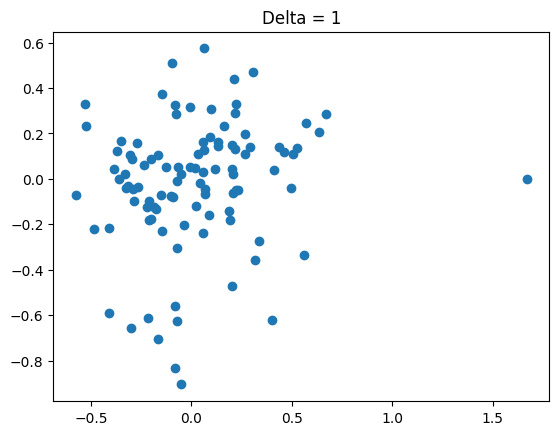

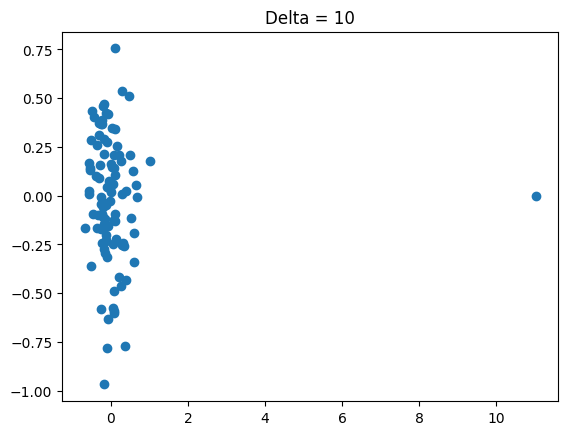

In [55]:
X, Y = worst_case_blob(num_samples=100, delta=1)
plot_clusters(X, Y, fignum="delta=1")
plt.title("Delta = 1")

X, Y = worst_case_blob(num_samples=100, delta=10)
plot_clusters(X, Y, fignum="delta=10")
plt.title("Delta = 10")

### Q1.2: While varying the parameter of `worst_case_blob`, try to select a value of $\epsilon$ that keeps the graph connected (the function `min_span_tree` can help you). What happens? Can you tell when it is a bad idea to use this approach?

In [56]:
from scipy.sparse.csgraph import connected_components

def eps_keep_graph_connected(X, var=1.0):
    sq_dist = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :])**2, axis=2)

    mst = min_span_tree(sq_dist)
    eps = np.exp(-np.max(sq_dist[mst])/(2 * var))

    return eps

Epsilon value for delta = 0.0: 0.934167233547619
Epsilon value for delta = 0.0001: 0.9256208122726696
Epsilon value for delta = 0.001: 0.8650608955523655
Epsilon value for delta = 0.01: 0.9101851810192516
Epsilon value for delta = 0.1: 0.9446361105313593
Epsilon value for delta = 1.0: 0.5787852805215472
Epsilon value for delta = 2: 0.1067931859367417
Epsilon value for delta = 3: 0.00822803272733974
Epsilon value for delta = 4: 0.0003227063790045373
Epsilon value for delta = 5: 3.6050412017478992e-06
Epsilon value for delta = 6: 1.520279394341399e-08
Epsilon value for delta = 7: 2.2509438314424925e-11
Epsilon value for delta = 8: 1.1916891336816602e-14
Epsilon value for delta = 9: 5.983444723254322e-19
Epsilon value for delta = 10: 4.10840694303098e-23
Epsilon value for delta = 20: 1.3419586394268957e-87


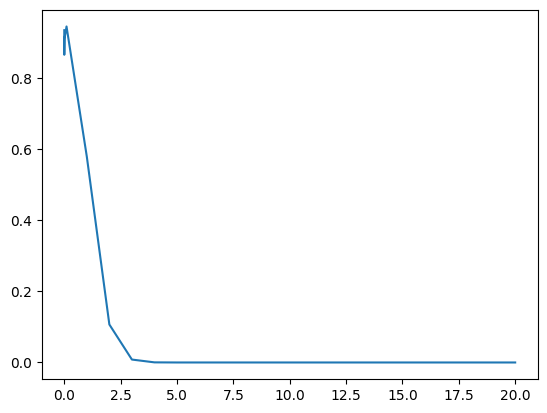

In [57]:
num_samples = 100
deltas = list(sorted([0.0, 1e-1, 1e-2, 1.0, 1e-3, 1e-4, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20]))
eps_list = []
for delta in deltas:
  X, Y = worst_case_blob(num_samples, delta=delta)
  eps = eps_keep_graph_connected(X, var=1.0)
  eps_list.append(eps)
  print(f"Epsilon value for delta = {delta}: {eps}")

plt.clf()
plt.plot(deltas, eps_list)
plt.show()

As the `delta` parameter increases, the distance between the outlier and the rest of the data increases. For fixed $\varepsilon$, the graph thus becomes disconnected.
We thus need to decrease its value as delta increases and end up giving more and more importance to the outlier, as seen on the above plot of epsilon as a function of delta.

The curve seems to be increasing for the first values, but this is only due to the fact that `delta` is small before the value of the variance in the main blob.

### Q1.3: Is it important to build a connected graph? Compare k-NN to $\epsilon$-graphs with respect to the difficulty of building a connected graph.

Having a connected graph is important for spectral clustering. If the graph is not connected the Laplacian will have a non-one multiplicity for its zero eigenvalue. In such cases, the spectral clustering algorithm would naturally separate these components, but this prevents the algorithm from finding relationships in different components.

To compare the difficulty:
 - $k$-NN is an easier solution to build a connected graph, as simply increasing $k$ up to $\lvert V \rvert - 1$ is enough to make completely sure that the graph is complete.
 - $\varepsilon$-neighbourood graphs are more difficult to render connected and are more easily filled with unhelpful edges. Indeed, considering a dataset whose points are placed on a circle and at its center. Then, the sublevel sets of the distance function from the center are equal for all values of epsilon smaller than the radius.
 Computing a practical $\epsilon$ is also more complicated than computing the optimal $k$, as shown by the MST heuristic.

### Q2.1: Build a graph starting from the data generated in `blobs`, and keep the graph connected. Use `spectral_clustering` to cluster the data. Motivate your choice on which eigenvectors to use and how you computed the clustering assignments from the eigenvectors. Now compute a similar clustering using the built-in k-means and compare the results.

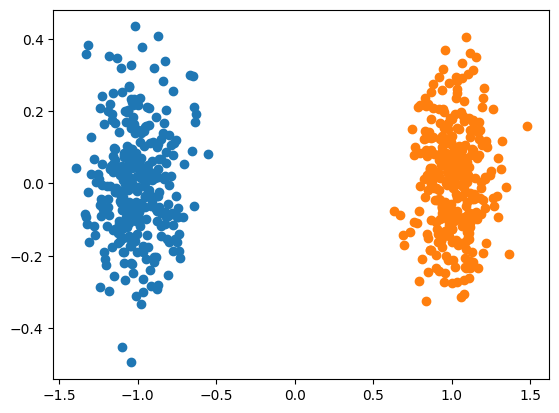

In [58]:
X, Y = blobs(num_samples=600)
plot_clusters(X, Y)

Calculated epsilon for connected graph: 0.4905


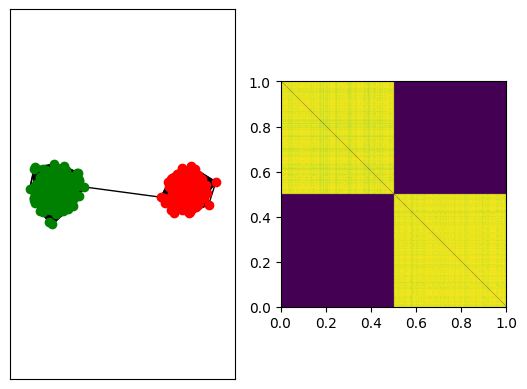

In [59]:
connected_eps = eps_keep_graph_connected(X, var=1.0)
print(f"Calculated epsilon for connected graph: {connected_eps:.4f}")

W = build_similarity_graph(X, var=1.0, eps=connected_eps, k=0)

# Plot the graph to visualize the connections
plot_graph_matrix(X, Y, W)

In [60]:
laplacian = build_laplacian(W, laplacian_normalization="sym")

Y_spectral = spectral_clustering(laplacian, chosen_eig_indices=[1, 2], num_classes=num_classes)
Y_kmeans = KMeans(n_clusters=num_classes, random_state=0, n_init=10).fit_predict(X)

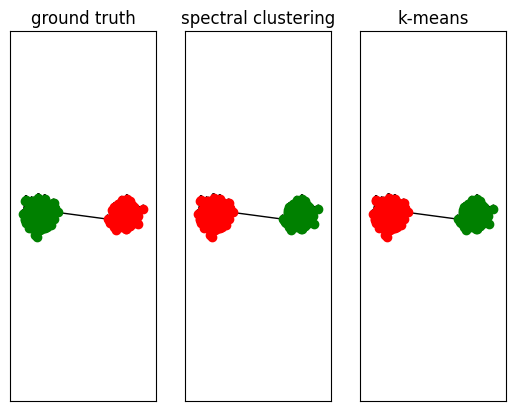

In [61]:
plot_clustering_result(X, Y, laplacian, Y_spectral, Y_kmeans)

In this, we chose eigenvectors 1 and 2 by increasing eigenvalues. Indeed, since the graph is connected, eigenvector 0 is associated to the connected component indicator, and using vectors 1 and 2 is done in the hope that they will represent something similar to indicators of the true clusters.

### Q2.2: Build a graph starting from the data generated in `blobs`, but this time make it so that the two components are separated. How do you choose which eigenvectors to use in this case? Motivate your answer.

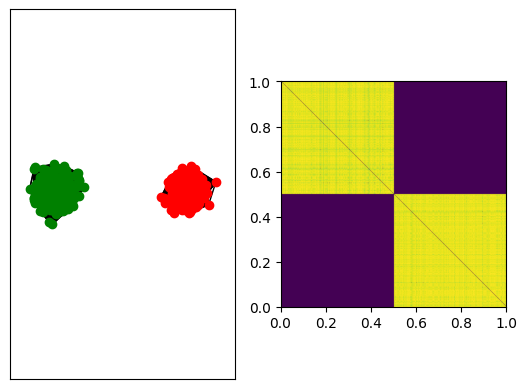

In [62]:
W = build_similarity_graph(X, var=1.0, eps=np.exp(-np.sqrt(2)/4))
plot_graph_matrix(X, Y, W)

We chose $\varepsilon = e^{-\sqrt{2}/4}$ as $\sqrt{2}/2$ is the distance between the centers of the two clusters in the definition of `blobs`.

Looking at the laplacian, it will now be a block matrix:

In [63]:
laplacian = build_laplacian(W)
print(laplacian)

[[279.62211539  -0.97959216  -0.94415112 ...   0.           0.
    0.        ]
 [ -0.97959216 290.0341446   -0.98932606 ...   0.           0.
    0.        ]
 [ -0.94415112  -0.98932606 291.66933007 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ... 281.92542419  -0.91640233
   -0.95454716]
 [  0.           0.           0.         ...  -0.91640233 287.67505935
   -0.97177266]
 [  0.           0.           0.         ...  -0.95454716  -0.97177266
  292.78649535]]


Here, we shift the eigenvector indices by one as the multiplicity of 0 as an eigenvalue is now 2, from the two connected components of the graph, but keep the same strategy for cluster inference.


In [64]:
Y_spectral = spectral_clustering(laplacian, chosen_eig_indices=[0, 1], num_classes=num_classes)
Y_kmeans = KMeans(n_clusters=num_classes, random_state=0, n_init=10).fit_predict(X)

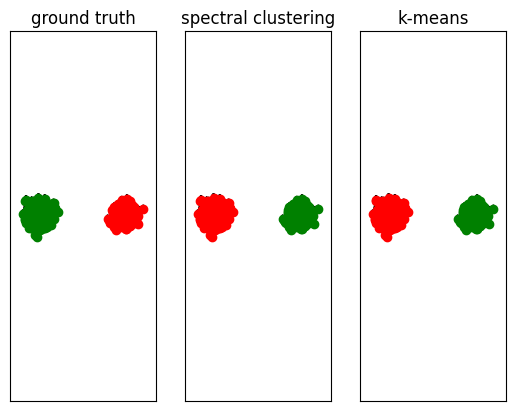

In [65]:
plot_clustering_result(X, Y, laplacian, Y_spectral, Y_kmeans)

### Q2.3: In the function spectral_clustering, implement an automatic strategy to choose the eigenvectors to use for clustering, when chosen_eig_indices=None. Explain your strategy. Generate a dataset with 4 blobs and test your function. What happens when the variance of the blobs increase?

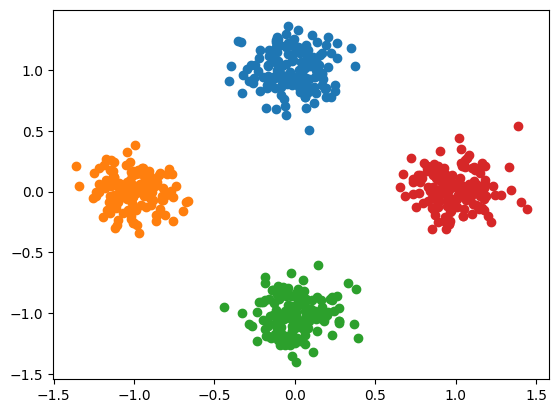

In [66]:
n_blobs = 4
X, Y = blobs(num_samples=600, n_blobs=4, blob_var=0.15)
plot_clusters(X, Y)

The implemented strategy examines the eigengap heuristic. We compute the gaps between consecutive eigenvalues excluding the first. The largest gap usually indicates the natural number of clusters (as other eigenvalues standalone bear less meaning).
Indeed, having small non-zero eigenvalues indicates the presence of clusters (zero eigenvalues indicating connected components). Then, the first $c$ non-zero eigenvalues will be significantly smaller than the $c + 1$-th: this gap captures the cutoff.

Here, to keep the graph disconnected, we use a graph generated with $k = 4$ and the knn method. The value of $4$ is arbitrary, and might be replaced with $\varepsilon = \exp\left(\frac{-\sqrt{2}}{16}\right)$ which works empirically.

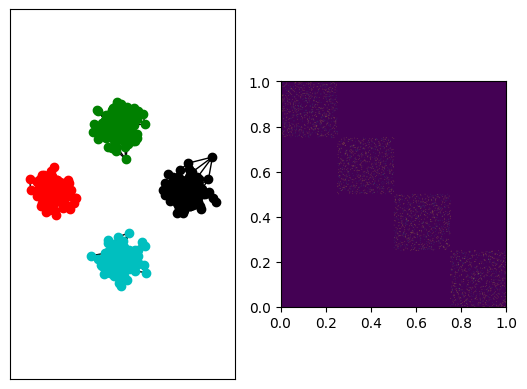

In [67]:
W = build_similarity_graph(X, k=4)
plot_graph_matrix(X, Y, W)

In [68]:
laplacian = build_laplacian(W, laplacian_normalization="sym")
print(laplacian)
Y_auto = spectral_clustering(laplacian, chosen_eig_indices=None, num_classes=n_blobs)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


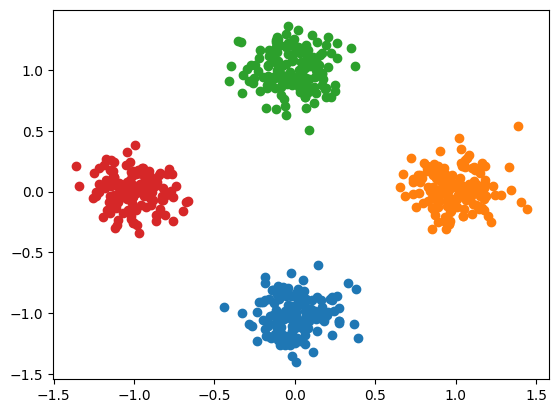

In [69]:
plot_clusters(X, Y_auto)

When the variance of the blobs increases, the blobs begin to overlap and our algorithm fails to recapture the exact clusters.

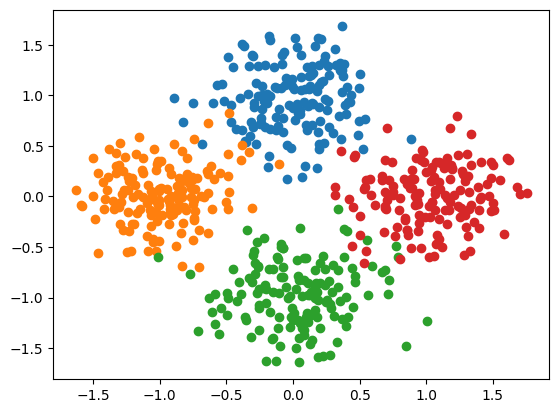

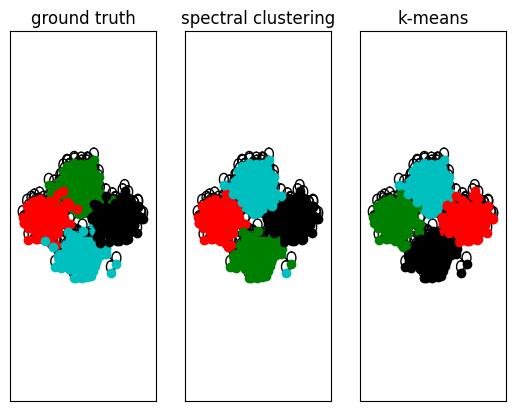

In [70]:
X, Y = blobs(num_samples=600, n_blobs=n_blobs, blob_var=0.3)
plot_clusters(X, Y)
eps = eps_keep_graph_connected(X)
W = build_similarity_graph(X, eps=eps)

L = build_laplacian(W)
Y_rec = spectral_clustering(L, chosen_eig_indices=None, num_classes=n_blobs)

# Plot results, comparing to KMeans
plot_clustering_result(X, Y, L, Y_rec, KMeans(4).fit_predict(X))

### Q2.4: When you built the cluster assignment, did you use thresholding, k-means or both? Do you have any opinion on when to use each?

When building the cluster assignment, we used $k$-means assignment on the chose eigenvectors, after normalizing them.

We rather use $k$-means than thresholding when the number of classes is greater than $2$. Thresholding only works directly for $2$ classes, and needs to be adapted otherwise.

Moreover, since the data here is noisy (as would be any real dataset), thresholding might lead to blurry results.


### Q2.5: Generate `two_moons` data and compare spectral clustering to k-means. Do you notice any difference? Taking into consideration the graph structure, can you explain them?

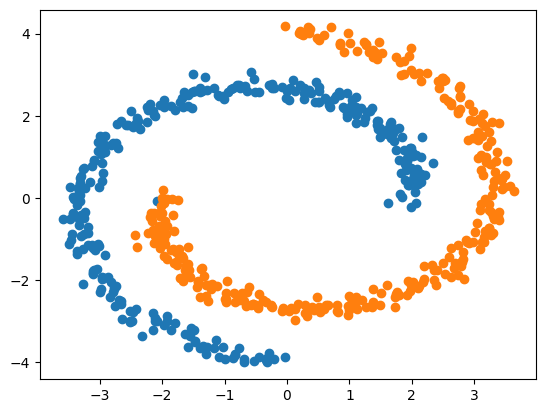

In [71]:
X, Y = two_moons(num_samples=600)
plot_clusters(X, Y)

When keeping the graph connected, we obtain this:

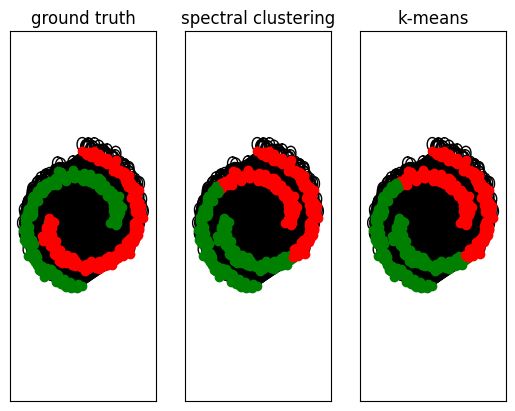

In [72]:
W = build_similarity_graph(X)

laplacian = build_laplacian(W)

Y_spectral = spectral_clustering(laplacian, chosen_eig_indices=None)
Y_kmeans = KMeans(n_clusters=num_classes, random_state=0, n_init=10).fit_predict(X)

plot_clustering_result(X, Y, laplacian, Y_spectral, Y_kmeans)

However, when using the $k$-nn strategy for building the graph (instead of using an $\varepsilon$ graph), we get the following:

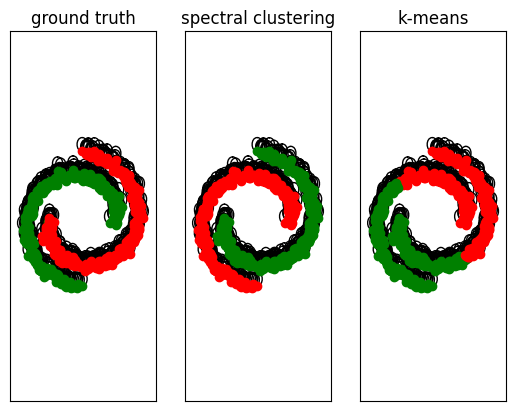

In [73]:
W = build_similarity_graph(X, k=10)

laplacian = build_laplacian(W, laplacian_normalization="unn")

Y_spectral = spectral_clustering(laplacian, chosen_eig_indices=None)
Y_kmeans = KMeans(n_clusters=num_classes, random_state=0, n_init=10).fit_predict(X)

plot_clustering_result(X, Y, laplacian, Y_spectral, Y_kmeans)

There is a fundamental difference between spectral clustering and $k$-means on this data. Our algorithm can separate the two moons into two clusters while $k$-means fails do to so. This comes from the fact that our graph mostly separates the two moons, but that this information is lost with $k$-means.

### Q2.6: Generate `point_and_circle` data and compare spectral clustering using the normal Laplacian and the random-walk regularized Laplacian. Do you notice any difference? Taking into consideration the graph structure, can you explain them?

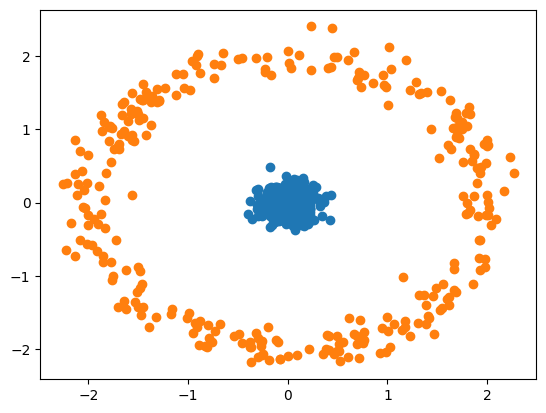

In [74]:
X, Y = point_and_circle(num_samples=600)
plot_clusters(X, Y)

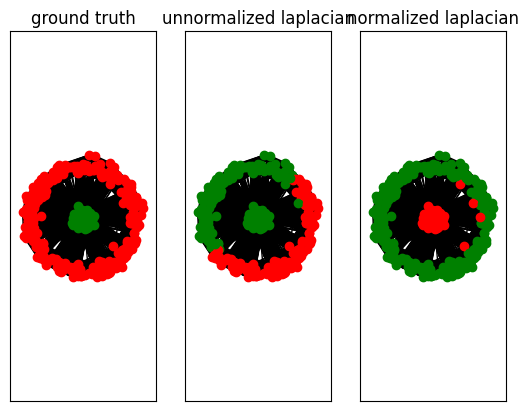

In [75]:
W = build_similarity_graph(X, eps=.25)

laplacian_unn = build_laplacian(W, laplacian_normalization="unn")
laplacian_rw = build_laplacian(W, laplacian_normalization="rw")

Y_spectral_unn = spectral_clustering(laplacian_unn, chosen_eig_indices=None)
Y_spectral_rw = spectral_clustering(laplacian_rw, chosen_eig_indices=None)

plot_clustering_result(X, Y, W, Y_spectral_unn, Y_spectral_rw, normalized_switch=1)

We notice that spectral clustering using the default unnormalized laplacian works much worse than using the random walk normalization of the laplacian. Indeed, this comes from the fact there is a large difference in degrees between points on the circle and at its center that disadvantages the unnormalized version.

### Q2.7: Using the function parameter_sensitivity, comment on the stability of spectral clustering when varying $\epsilon$ or k.

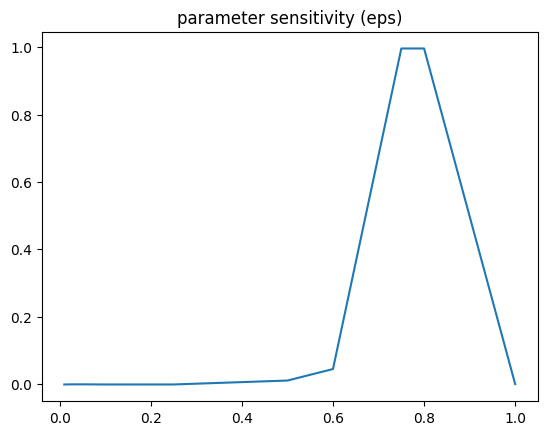

In [76]:
parameter_sensitivity(parameter_type='eps', parameter_candidate=[0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 0.6, 0.75, 0.8, 1], num_samples=1000)

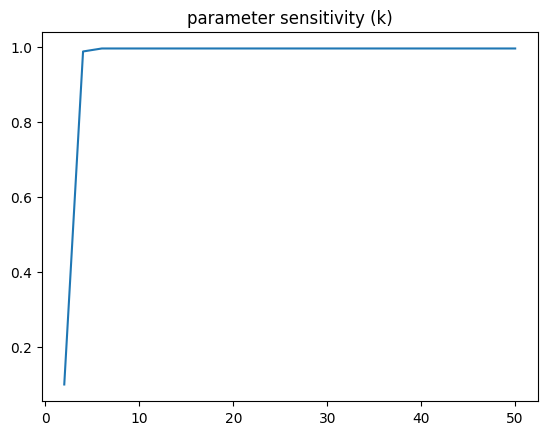

In [77]:
parameter_sensitivity(parameter_type='k', parameter_candidate=[2, 4, 6, 8, 10, 15, 18, 20, 50], num_samples=1000)

Spectral clustering is extremely sensitive to the choice of $\epsilon$ or k, since they control the structure of the similarity graph. If $\epsilon$ is too small or k is too small, the graph will be disconnected and spectral clustering will fail to capture the structure of the data. On the other hand, if $\epsilon$ is too large or k is too large, the graph will be too dense and spectral clustering will also fail to capture the structure of the data as it will not be able to recognize the difference between different clusters that are too interconnected. Therefore, it is crucial to choose these parameters carefully to ensure good clustering results.

### Q2.8: If we did not have access to "true" labels, how could we evaluate the clustering result (or what should we not use as evaluation)?

We could use something like the RatioCut to evaluate the clustering result for different parameters of the similarity graph.

Methods that rely purely on the geometric structure of the underlying point space (like $k$-means inertia) should only be used when the embedding is used for building the similarities graph. Otherwise, one should not do so.

### Q3.1: Complete all the code necessary, and cluster the `four_elements` and `fruit_salad` images in the data folder and include here some images of the clustering.  Explain your design choices in the overall pipeline (e.g. which graph, which pre-processing...) and how you think they impact the results you are seeing. Report also at least one failure mode for the algorithm.

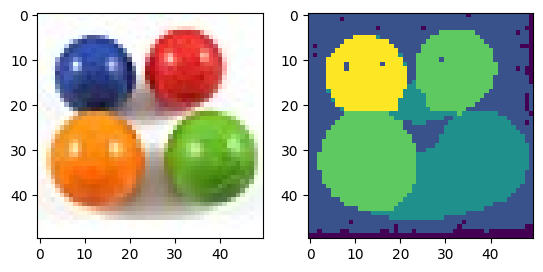

In [78]:
image_segmentation(input_img="four_elements.bmp")

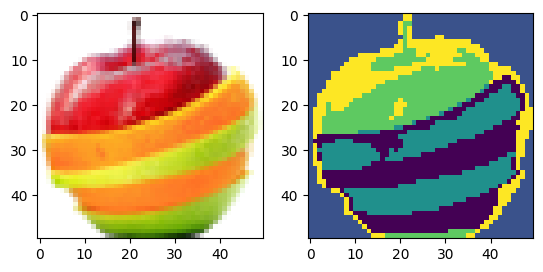

In [79]:
image_segmentation(input_img="fruit_salad.bmp", var=1.0, k=15, laplacian_normalization="sym", chosen_eig_indices=None, num_classes=5)

### Q3.2: A full graph built between the pixels of a 50 × 50 image corresponds to $50^2$ nodes. Solving the full eigenvalue problem in this case would scale in the order of $2^{34}$ . Even on weak hardware this takes only seconds to minutes. Segmenting a Full HD picture of 1920 × 1080 would scale in the order of $2^{64}$ (about a month on a decent machine). Beyond that, the large picture would require to store in memory a graph over millions of nodes. A full graph on that scale requires about 1TB of memory. Can you think two simple techniques to reduce the computational and occupational cost of Spectral Clustering?

Representing the graph as a sparse weight matrix instead of a full graph can already reduce the space needed in RAM and the computational cost of the clustering algorithm. Indeed, the graph that are built with $k$-nn and $\varepsilon$-graphs are sparse.

We could also downscale the resolution to reduce the number of nodes in the graph, at the cost of blurrier clusters when rescaling at the end, but this is fine for a task such as image segmentation.

Last, but not least, one could use approximations for the computations of the distances, the normalized laplacian matrix and the eigenspace decomposition.

### Q3.3: Choose a larger image of your choice, and try to implement some of the scalability modifications to run spectral clustering on it. Report some examples of the results you achieve.

We use the `sparse` module of scipy for handling the sparse matrices, instead of doing it "by hand"

In [80]:
from scipy import sparse
from sklearn.neighbors import NearestNeighbors

def sparse_build_similarity_graph(X, var=1.0, eps=0.0, k=0):
    n = X.shape[0]

    if k != 0:
        actual_k = min(k + 1, n)

        # We use sklearn as their implementation is faster, built on KDTrees
        nn = NearestNeighbors(n_neighbors=actual_k, metric='euclidean', n_jobs=-1)
        nn.fit(X)

        distances, indices = nn.kneighbors(X)
        weights = np.exp(-distances**2 / (2 * var))

        rows = np.repeat(np.arange(n), actual_k)
        cols = indices.flatten()
        data = weights.flatten()

        W = sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

        W.setdiag(0)
        W.eliminate_zeros()

        W = (W + W.T) / 2

    else:
        # We only compute neighbours in a radius using sklearn NearestNeighbours
        radius = np.sqrt(-2 * var * np.log(eps)) if eps > 0 else 1.0

        nn = NearestNeighbors(radius=radius, metric='euclidean', n_jobs=-1)
        nn.fit(X)

        # adj_matrix is euclidean distance
        adj_matrix = nn.radius_neighbors_graph(X, radius=radius, mode='distance')
        adj_matrix.data = np.exp(-(adj_matrix.data**2) / (2 * var))

        W = adj_matrix
        W.setdiag(0)
        W.eliminate_zeros()

    return W

In [81]:
def sparse_build_laplacian(W, laplacian_normalization='unn'):
    n = W.shape[0]
    d = np.array(W.sum(axis=1)).flatten()

    if laplacian_normalization == 'unn':
        # L = D - W
        D = sparse.diags(d, format='csr')
        return D - W

    d_inv = np.divide(1.0, d, out=np.zeros_like(d), where=d != 0)
    d_inv_sqrt = np.sqrt(d_inv)

    if laplacian_normalization == 'sym':
        # L = I - D^-1/2 * W * D^-1/2
        D_inv_sqrt = sparse.diags(d_inv_sqrt, format='csr')
        return sparse.eye(n, format='csr') - D_inv_sqrt.dot(W).dot(D_inv_sqrt)

    if laplacian_normalization == 'rw':
        # L = I - D^-1 * W
        D_inv = sparse.diags(d_inv, format='csr')
        return sparse.eye(n, format='csr') - D_inv.dot(W)

    raise ValueError("Invalid normalization. Choose 'unn', 'sym', or 'rw'.")


In [82]:
from scipy.sparse import linalg
from sklearn.cluster import KMeans

def sparse_spectral_clustering(L, chosen_eig_indices=None, num_classes=2):
    n_samples = L.shape[0]

    # We only compute a certain maximal number of eigenvectors to reduce compute time
    if chosen_eig_indices is not None:
        k_to_compute = max(chosen_eig_indices) + 1
    else:
        k_to_compute = num_classes if num_classes is not None else 10

    # we use eigsh instead of eigh since matrices are sparse now
    eigvals, eigvecs = linalg.eigsh(L, k=k_to_compute, which='SM')

    idx_sorted = np.argsort(eigvals)
    eigvals = eigvals[idx_sorted]
    eigvecs = eigvecs[:, idx_sorted]

    # eigengap heuristic
    if chosen_eig_indices is None:
        gaps = np.diff(eigvals)
        k_optimal = np.argmax(gaps) + 1

        k = k_optimal if num_classes is None else num_classes
        chosen_eig_indices = np.arange(k)
    else:
        k = len(chosen_eig_indices)

    U = eigvecs[:, chosen_eig_indices]

    row_norms = np.linalg.norm(U, axis=1, keepdims=True)
    U_normalized = np.divide(U, row_norms, out=np.zeros_like(U), where=row_norms != 0)

    kmeans = KMeans(n_clusters=len(np.unique(chosen_eig_indices)) if num_classes is None else num_classes,
                    random_state=42,
                    n_init=10)
    Y = kmeans.fit_predict(U_normalized)

    return Y

In [83]:
from skimage import io, transform

def sparse_image_segmentation(input_img="four_elements.bmp", var=1.0, k=20,
                               laplacian_normalization="sym", chosen_eig_indices=None,
                               num_classes=5, downscale_factor=1.0):

    filename = os.path.join("data", input_img)
    img = io.imread(filename)

    # downscale the image
    if downscale_factor != 1.0:
        img_work = transform.rescale(img, downscale_factor, anti_aliasing=True,
                                     channel_axis=-1 if img.ndim == 3 else None)
    else:
        img_work = img

    img_work = (img_work - np.min(img_work)) / (np.max(img_work) - np.min(img_work))

    h, w = img_work.shape[:2]
    Xr = img_work.reshape(h * w, -1)

    W = sparse_build_similarity_graph(Xr, var=var, k=k)
    L = sparse_build_laplacian(W, laplacian_normalization)
    Y_rec = sparse_spectral_clustering(L, chosen_eig_indices=chosen_eig_indices, num_classes=num_classes)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Original (unscaled) image")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Spectral segmentation (k={num_classes})")
    Y_plot = Y_rec.reshape(h, w)
    plt.imshow(Y_plot, cmap='viridis')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return Y_rec

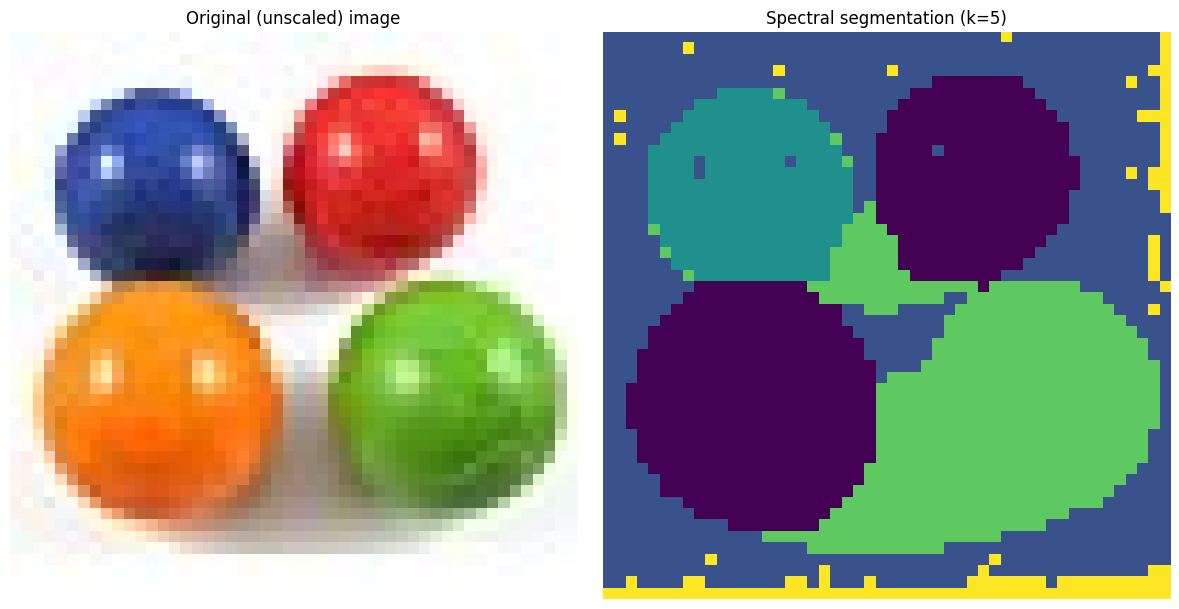

array([1, 1, 1, ..., 4, 4, 4], dtype=int32)

In [84]:
sparse_image_segmentation()

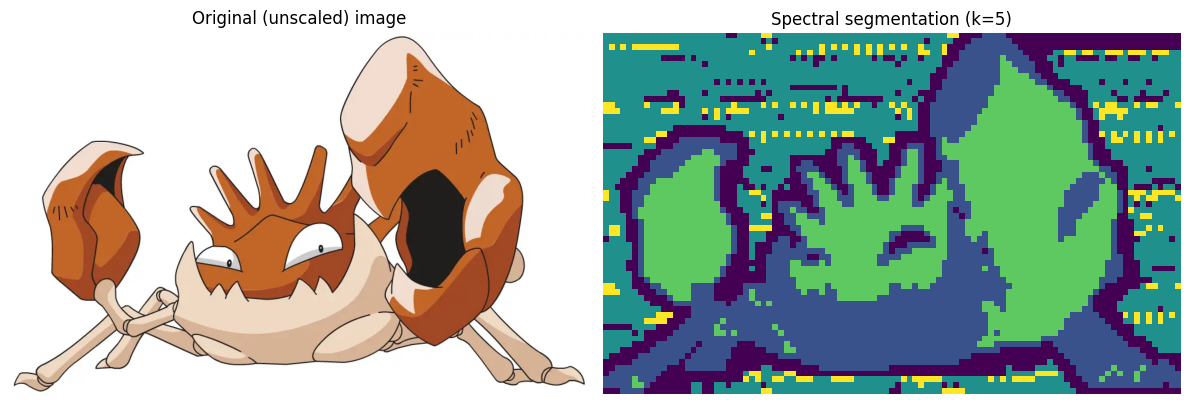

Took 2.9860265254974365s


In [85]:
import time as time
start = time.time()
sparse_image_segmentation("krabboss.bmp", downscale_factor=.1)
end = time.time()
print(f"Took {end - start}s")

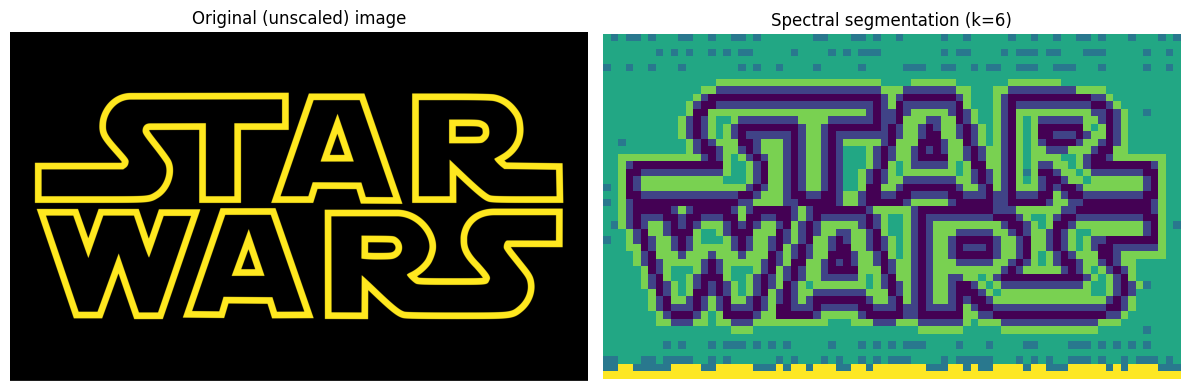

Took 20.397775888442993s


In [87]:
import time as time
start = time.time()
sparse_image_segmentation("sw.bmp", downscale_factor=2e-2, num_classes=6)
end = time.time()
print(f"Took {end - start}s")